In [2]:
import csv
import math

rows = []
with open('dataset_processed.csv', 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

feature_cols = [c for c in rows[0].keys() if c not in ('url', 'status')]
n = len(rows)
print(n, "rows,", len(feature_cols), "features")

11430 rows, 48 features


In [3]:
X = [[float(r[col]) for col in feature_cols] for r in rows]
y = [1 if r['status'] == 'phishing' else 0 for r in rows]

In [4]:
split_train = int(0.6 * n)
split_val   = int(0.8 * n)

X_train = X[:split_train]
y_train = y[:split_train]

X_val   = X[split_train:split_val]
y_val   = y[split_train:split_val]

X_test  = X[split_val:]
y_test  = y[split_val:]

print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

Train: 6858
Val  : 2286
Test : 2286


In [5]:
def gini(groups, classes):
    total = sum(len(g) for g in groups)
    score = 0.0
    for group in groups:
        size = len(group)
        if size == 0:
            continue
        proportions = [group.count(c) / size for c in classes]
        score += (1 - sum(p ** 2 for p in proportions)) * (size / total)
    return score

def best_split(X, y, depth=1):
    best_idx, best_val, best_score, best_groups = None, None, 1, None
    classes = list(set(y))
    total_cols = len(X[0])
    for col in range(total_cols):
        print(f"  Depth {depth} — scanning feature {col+1}/{total_cols}", end='\r')
        for row in X:
            val = row[col]
            left_y  = [y[i] for i in range(len(X)) if X[i][col] < val]
            right_y = [y[i] for i in range(len(X)) if X[i][col] >= val]
            if not left_y or not right_y:
                continue
            score = gini([left_y, right_y], classes)
            if score < best_score:
                best_idx, best_val, best_score = col, val, score
                best_groups = (
                    [(X[i], y[i]) for i in range(len(X)) if X[i][col] < val],
                    [(X[i], y[i]) for i in range(len(X)) if X[i][col] >= val]
                )
    print()
    return best_idx, best_val, best_groups

def to_leaf(pairs):
    labels = [p[1] for p in pairs]
    return max(set(labels), key=labels.count)

def build_tree(pairs, max_depth, min_size, depth=1):
    X = [p[0] for p in pairs]
    y = [p[1] for p in pairs]
    print(f"Building depth {depth}/{max_depth} — {len(pairs)} samples")
    idx, val, groups = best_split(X, y, depth)
    if not groups or idx is None:
        return to_leaf(pairs)
    left_pairs, right_pairs = groups
    if depth >= max_depth:
        return {'idx': idx, 'val': val,
                'left': to_leaf(left_pairs),
                'right': to_leaf(right_pairs)}
    node = {'idx': idx, 'val': val}
    node['left']  = to_leaf(left_pairs)  if len(left_pairs)  <= min_size else build_tree(left_pairs,  max_depth, min_size, depth + 1)
    node['right'] = to_leaf(right_pairs) if len(right_pairs) <= min_size else build_tree(right_pairs, max_depth, min_size, depth + 1)
    return node

def predict_one(node, row):
    if not isinstance(node, dict):
        return node
    if row[node['idx']] < node['val']:
        return predict_one(node['left'], row)
    return predict_one(node['right'], row)

print("Building tree...")
pairs = list(zip(X_train, y_train))
tree  = build_tree(pairs, max_depth=5, min_size=10)
print("Tree built.")



Building tree...
Building depth 1/5 — 6858 samples
  Depth 1 — scanning feature 48/48
Building depth 2/5 — 3170 samples
  Depth 2 — scanning feature 48/48
Building depth 3/5 — 165 samples
  Depth 3 — scanning feature 48/48
Building depth 4/5 — 88 samples
  Depth 4 — scanning feature 48/48
Building depth 5/5 — 22 samples
  Depth 5 — scanning feature 48/48
Building depth 5/5 — 66 samples
  Depth 5 — scanning feature 48/48
Building depth 4/5 — 77 samples
  Depth 4 — scanning feature 48/48
Building depth 5/5 — 58 samples
  Depth 5 — scanning feature 48/48
Building depth 5/5 — 19 samples
  Depth 5 — scanning feature 48/48
Building depth 3/5 — 3005 samples
  Depth 3 — scanning feature 48/48
Building depth 4/5 — 2839 samples
  Depth 4 — scanning feature 48/48
Building depth 5/5 — 102 samples
  Depth 5 — scanning feature 48/48
Building depth 5/5 — 2737 samples
  Depth 5 — scanning feature 48/48
Building depth 4/5 — 166 samples
  Depth 4 — scanning feature 48/48
Building depth 5/5 — 88 samples


In [6]:
y_pred = [predict_one(tree, row) for row in X_test]
print("Predictions done.")

Predictions done.


In [7]:
TP = sum(1 for a, p in zip(y_test, y_pred) if a == 1 and p == 1)
TN = sum(1 for a, p in zip(y_test, y_pred) if a == 0 and p == 0)
FP = sum(1 for a, p in zip(y_test, y_pred) if a == 0 and p == 1)
FN = sum(1 for a, p in zip(y_test, y_pred) if a == 1 and p == 0)

accuracy    = (TP + TN) / (TP + TN + FP + FN)
precision   = TP / (TP + FP) if (TP + FP) > 0 else 0
recall      = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
fmeasure    = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
gmean       = math.sqrt(recall * specificity)

print("=" * 35)
print("CONFUSION MATRIX")
print("=" * 35)
print(f"                Predicted")
print(f"              Phish   Legit")
print(f"Actual Phish   {TP:4d}    {FN:4d}")
print(f"Actual Legit   {FP:4d}    {TN:4d}")
print("=" * 35)
print("PERFORMANCE METRICS")
print("=" * 35)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F-Measure   : {fmeasure:.4f}")
print(f"G-Mean      : {gmean:.4f}")

CONFUSION MATRIX
                Predicted
              Phish   Legit
Actual Phish   1047      63
Actual Legit     85    1091
PERFORMANCE METRICS
Accuracy    : 0.9353
Precision   : 0.9249
Recall      : 0.9432
Specificity : 0.9277
F-Measure   : 0.9340
G-Mean      : 0.9354


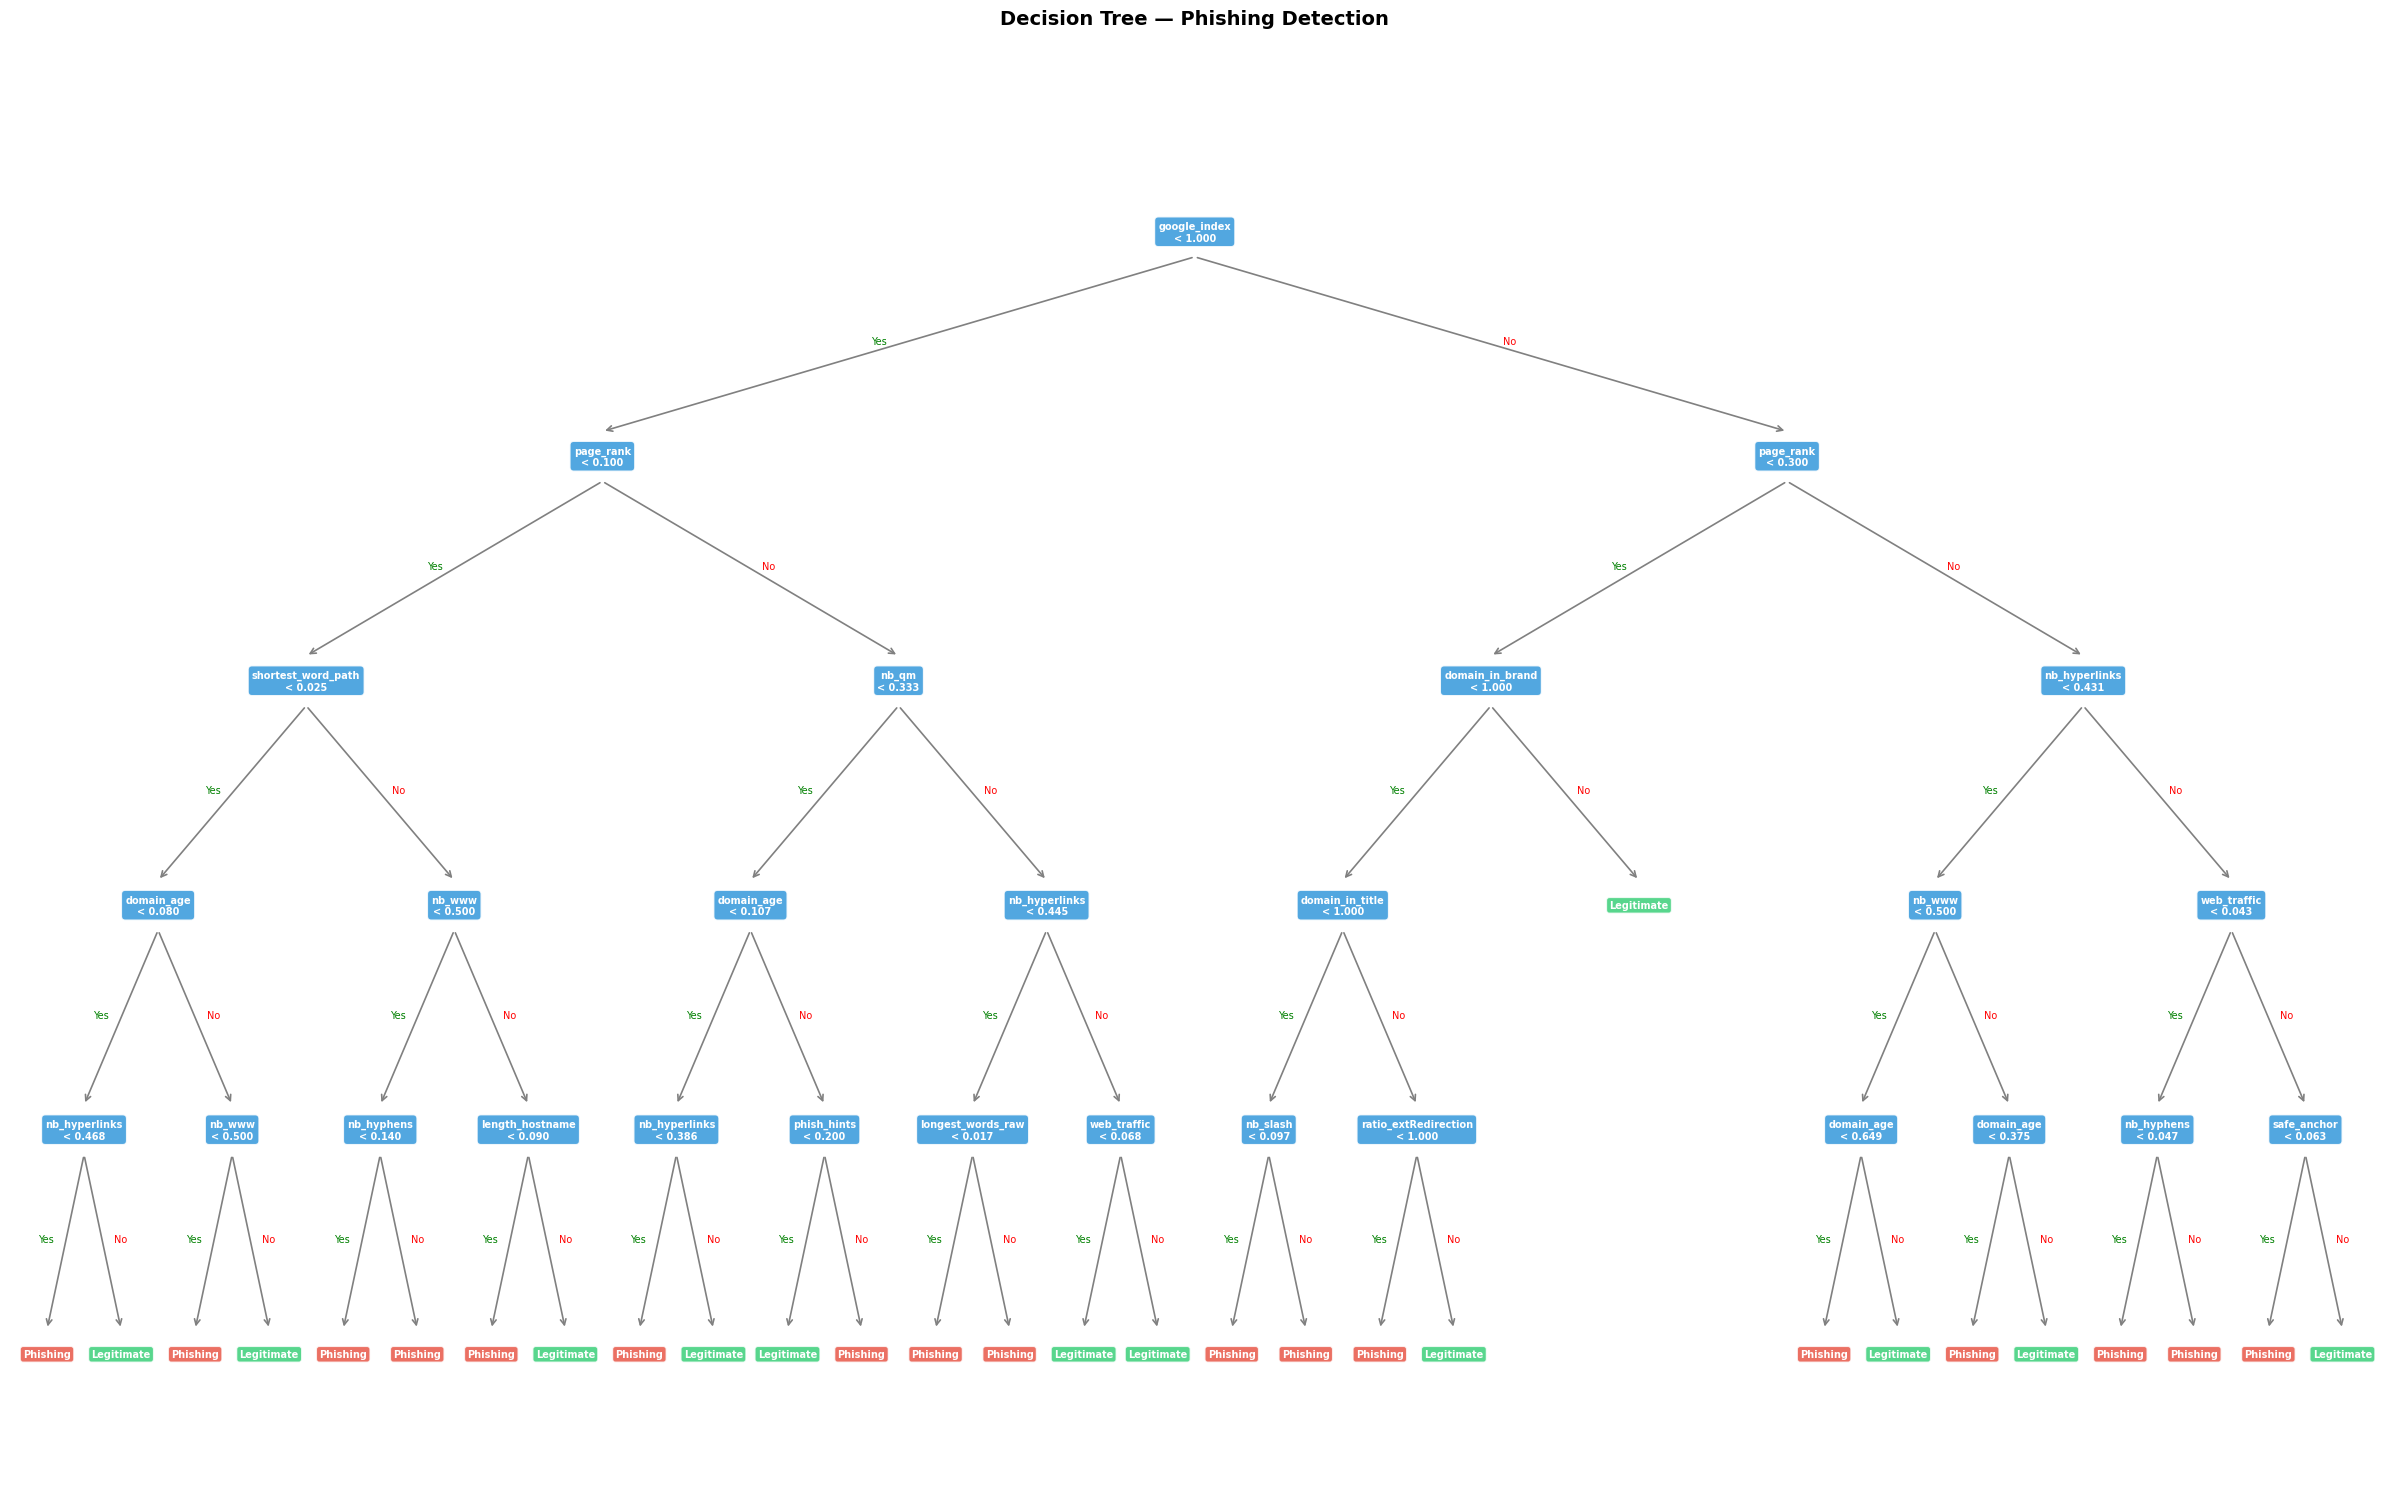

Saved: decision_tree.png


In [8]:
import matplotlib.pyplot as plt

def get_tree_depth(node):
    if not isinstance(node, dict):
        return 0
    return 1 + max(get_tree_depth(node['left']), get_tree_depth(node['right']))

def count_leaves(node):
    if not isinstance(node, dict):
        return 1
    return count_leaves(node['left']) + count_leaves(node['right'])

def draw_tree(ax, node, x, y, dx, dy, depth=0):
    if not isinstance(node, dict):
        color = '#2ecc71' if node == 0 else '#e74c3c'
        label = 'Legitimate' if node == 0 else 'Phishing'
        ax.text(x, y, label, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8, edgecolor='white'),
                color='white', fontweight='bold')
        return

    feature_name = feature_cols[node['idx']]
    label = f"{feature_name}\n< {node['val']:.3f}"
    ax.text(x, y, label, ha='center', va='center', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#3498db', alpha=0.85, edgecolor='white'),
            color='white', fontweight='bold')

    # left child
    lx, ly = x - dx, y - dy
    ax.annotate('', xy=(lx, ly + 0.02), xytext=(x, y - 0.02),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
    ax.text((x + lx) / 2 - 0.01, (y + ly) / 2, 'Yes',
            fontsize=7, color='green', ha='right')
    draw_tree(ax, node['left'],  lx, ly, dx / 2, dy, depth + 1)

    # right child
    rx, ry = x + dx, y - dy
    ax.annotate('', xy=(rx, ry + 0.02), xytext=(x, y - 0.02),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
    ax.text((x + rx) / 2 + 0.01, (y + ry) / 2, 'No',
            fontsize=7, color='red', ha='left')
    draw_tree(ax, node['right'], rx, ry, dx / 2, dy, depth + 1)

# -- plot --
depth      = get_tree_depth(tree)
fig_width  = min(24, count_leaves(tree) * 1.5)
fig_height = (depth + 1) * 2.5

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 0.15)
ax.axis('off')
ax.set_title('Decision Tree — Phishing Detection', fontsize=14, fontweight='bold', pad=15)

draw_tree(ax, tree, x=0, y=0, dx=0.5, dy=0.18)

plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: decision_tree.png")

In [10]:
import math

def evaluate(y_true, y_pred, label=""):
    TP = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 1)
    TN = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 0)
    FP = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 1)
    FN = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 0)
    total = TP + TN + FP + FN

    # --- primary metrics ---
    accuracy        = (TP + TN) / total
    error_rate      = (FP + FN) / total
    precision       = TP / (TP + FP)                          if (TP + FP) > 0 else 0
    recall          = TP / (TP + FN)                          if (TP + FN) > 0 else 0
    specificity     = TN / (TN + FP)                          if (TN + FP) > 0 else 0
    npv             = TN / (TN + FN)                          if (TN + FN) > 0 else 0
    f1              = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    balanced_acc    = (recall + specificity) / 2

    # --- advanced metrics ---
    mcc_num         = (TP * TN) - (FP * FN)
    mcc_den         = math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc             = mcc_num / mcc_den                       if mcc_den > 0 else 0
    kappa           = mcc                                     # same formula for balanced dataset
    youden_j        = recall + specificity - 1
    gmean           = math.sqrt(recall * specificity)
    fmeasure        = f1                                      # same as F1

    # --- error rates ---
    fpr             = FP / (FP + TN)                          if (FP + TN) > 0 else 0
    fnr             = FN / (FN + TP)                          if (FN + TP) > 0 else 0

    # --- likelihood ratios ---
    lr_pos          = recall / fpr                            if fpr > 0 else 0
    lr_neg          = fnr / specificity                       if specificity > 0 else 0
    dor             = lr_pos / lr_neg                         if lr_neg > 0 else 0

    # --- prevalence and detection ---
    prevalence      = (TP + FN) / total
    detection_rate  = TP / total
    detection_prev  = (TP + FP) / total

    # --- per class ---
    prec_legit      = TN / (TN + FN)                          if (TN + FN) > 0 else 0
    rec_legit       = TN / (TN + FP)                          if (TN + FP) > 0 else 0
    f1_legit        = 2 * prec_legit * rec_legit / (prec_legit + rec_legit) if (prec_legit + rec_legit) > 0 else 0
    macro_prec      = (precision + prec_legit) / 2
    macro_rec       = (recall + rec_legit) / 2
    macro_f1        = (f1 + f1_legit) / 2

    n_legit         = TN + FP
    n_phish         = TP + FN
    weighted_prec   = (precision * n_phish + prec_legit * n_legit) / total
    weighted_rec    = (recall    * n_phish + rec_legit  * n_legit) / total
    weighted_f1     = (f1        * n_phish + f1_legit   * n_legit) / total

    print("=" * 50)
    print(f"  {label}")
    print("=" * 50)

    print("\n  CONFUSION MATRIX")
    print(f"                   Predicted")
    print(f"               Legit    Phish")
    print(f"  Actual Legit   {TN:4d}     {FP:4d}")
    print(f"  Actual Phish   {FN:4d}     {TP:4d}")

    print("\n  PRIMARY METRICS")
    print(f"  Accuracy                   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Error Rate                 : {error_rate:.4f}  ({error_rate*100:.2f}%)")
    print(f"  Precision (Phishing)       : {precision:.4f}")
    print(f"  Recall / Sensitivity       : {recall:.4f}")
    print(f"  Specificity                : {specificity:.4f}")
    print(f"  NPV                        : {npv:.4f}")
    print(f"  F1-Score                   : {f1:.4f}")
    print(f"  F-Measure                  : {fmeasure:.4f}")
    print(f"  G-Mean                     : {gmean:.4f}")
    print(f"  Balanced Accuracy          : {balanced_acc:.4f}")

    print("\n  ADVANCED METRICS")
    print(f"  MCC                        : {mcc:.4f}")
    print(f"  Cohen's Kappa              : {kappa:.4f}")
    print(f"  Youden's J Statistic       : {youden_j:.4f}")
    print(f"  Diagnostic Odds Ratio      : {dor:.4f}")
    print(f"  Positive Likelihood Ratio  : {lr_pos:.4f}")
    print(f"  Negative Likelihood Ratio  : {lr_neg:.4f}")

    print("\n  ERROR ANALYSIS")
    print(f"  False Positive Rate (FPR)  : {fpr:.4f}  ({fpr*100:.2f}%)")
    print(f"  False Negative Rate (FNR)  : {fnr:.4f}  ({fnr*100:.2f}%)")
    print(f"  Prevalence                 : {prevalence:.4f}  ({prevalence*100:.2f}%)")
    print(f"  Detection Rate             : {detection_rate:.4f}  ({detection_rate*100:.2f}%)")
    print(f"  Detection Prevalence       : {detection_prev:.4f}  ({detection_prev*100:.2f}%)")

    print("\n  PER CLASS REPORT")
    print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'Legitimate':<12} {prec_legit:>10.4f} {rec_legit:>10.4f} {f1_legit:>10.4f} {n_legit:>10}")
    print(f"  {'Phishing':<12} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {n_phish:>10}")
    print(f"  {'Macro Avg':<12} {macro_prec:>10.4f} {macro_rec:>10.4f} {macro_f1:>10.4f} {total:>10}")
    print(f"  {'Weighted Avg':<12} {weighted_prec:>10.4f} {weighted_rec:>10.4f} {weighted_f1:>10.4f} {total:>10}")
    print("=" * 50)

In [11]:
train_pred = [predict_one(tree, row) for row in X_train]
val_pred   = [predict_one(tree, row) for row in X_val]
test_pred  = [predict_one(tree, row) for row in X_test]

evaluate(y_train, train_pred, "TRAINING SET")
evaluate(y_val,   val_pred,   "VALIDATION SET")
evaluate(y_test,  test_pred,  "TEST SET")

  TRAINING SET

  CONFUSION MATRIX
                   Predicted
               Legit    Phish
  Actual Legit   3195      226
  Actual Phish    188     3249

  PRIMARY METRICS
  Accuracy                   : 0.9396  (93.96%)
  Error Rate                 : 0.0604  (6.04%)
  Precision (Phishing)       : 0.9350
  Recall / Sensitivity       : 0.9453
  Specificity                : 0.9339
  NPV                        : 0.9444
  F1-Score                   : 0.9401
  F-Measure                  : 0.9401
  G-Mean                     : 0.9396
  Balanced Accuracy          : 0.9396

  ADVANCED METRICS
  MCC                        : 0.8793
  Cohen's Kappa              : 0.8793
  Youden's J Statistic       : 0.8792
  Diagnostic Odds Ratio      : 244.3173
  Positive Likelihood Ratio  : 14.3092
  Negative Likelihood Ratio  : 0.0586

  ERROR ANALYSIS
  False Positive Rate (FPR)  : 0.0661  (6.61%)
  False Negative Rate (FNR)  : 0.0547  (5.47%)
  Prevalence                 : 0.5012  (50.12%)
  Detection Rat